In [1]:
%cd ..
!git clone https://github.com/dodo47/GCDetection

/home/ludi/Documents/Uni/magistrale/AII/AII-Assignment
fatal: destination path 'GCDetection' already exists and is not an empty directory.


Load the datasets using utils.data.prepare_data()

In [2]:
from utils import data

FCC, VCC = data.prepare_data()

Data Exploration

<Axes: xlabel='pGC', ylabel='Count'>

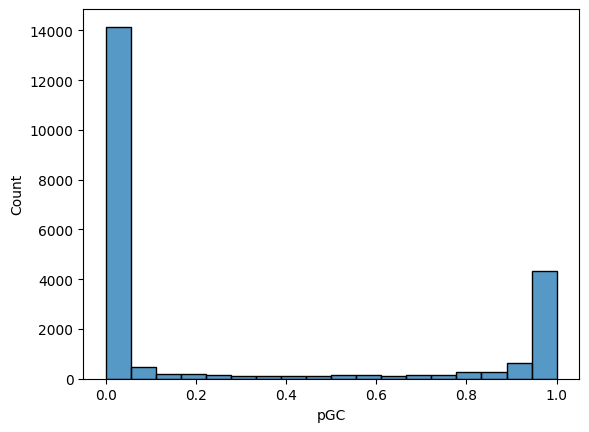

In [3]:
import seaborn as sns

sns.histplot(FCC["pGC"])

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np



class ConvGp(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, M, padding=0, stride=1, s=1.0, ls=1.0):
        super().__init__()
        self.k = kernel_size
        self.out_channels = out_channels
        self.P = in_channels * kernel_size * kernel_size 
        self.M = M 
        self.padding = padding
        self.stride = stride
        self.Z = nn.Parameter(torch.randn(M, self.P))
        self.log_s = nn.Parameter(torch.log(torch.tensor(s)))
        self.log_ls = nn.Parameter(torch.log(torch.tensor(ls)))
    
    @property
    def sigma(self): return self.log_s.exp()

    @property
    def lengthscale(self): return self.log_ls.exp()

    def _rbf(self, x1, x2, s, ls):
        """Kernel RBF modulare con gestione automatica del broadcasting."""
        # Se x1 è (N, L, P) e x2 è (M, P), cdist richiede x2 (1, M, P)
        if x1.dim() == 3 and x2.dim() == 2:
            x2 = x2.unsqueeze(0)
            
        dist_sq = torch.cdist(x1, x2, p=2)**2
        return (s**2) * torch.exp(-dist_sq / (2 * (ls**2)))

class ExtractorConvGP(ConvGp):
    def __init__(self, in_channels, out_channels, kernel_size, M, padding=0, stride=1, s=1.0, ls=1.0):
        super().__init__(in_channels, out_channels, kernel_size, M, padding, stride, s, ls)
        self.m = nn.Parameter(torch.randn(M, out_channels)) # Inducing responses
        self.L_S_raw = nn.Parameter(torch.eye(M)) # Posterior learned covariance.

    def forward(self, x):

        N, C, H, W = x.shape
        s = self.sigma
        ls = self.lengthscale

        # Input unfolding (patch extraction, L=num patches): 
        # (N, C, H, W) -> (N, L, P)
        patches = F.unfold(x, kernel_size=self.k, padding=self.padding, stride=self.stride).transpose(1, 2)
        L = patches.shape[1]

        # Similarity matrixes.
        # K_zz: add jitter for numerical stability and invertibility.
        K_zz = self._rbf(self.Z, self.Z, s, ls) + 1e-5 * torch.eye(self.M, device=x.device) # (M, M)
        K_xz = self._rbf(patches, self.Z.unsqueeze(0), s, ls) # (N, L, M)

        # Cholesky decomposition to avoid direct matrix inversion.
        L_z = torch.linalg.cholesky(K_zz)
        # A = K_xz @ K_zz^-1
        A = torch.cholesky_solve(K_xz.transpose(1, 2), L_z).transpose(1, 2) # (N, L, M)

        # Predictive mean: (N, L, M) @ (M, out) -> (N, L, out)
        mean = torch.matmul(A, self.m)

        # Predictive variance: 
        # Extract S from L_S_raw.
        L_S = torch.tril(self.L_S_raw)
        S = L_S @ L_S.T

        # The followinf is an efficient formula to compute the posterior variance 
        # (diag(covariance)) of the query variables.

        # Difference between prior covariance and posterior covariance (learned).
        # This represents "uncertainty reduction". 
        K_diff = K_zz - S
        
        # - torch.matmul(A, K_diff) Transports uncertainty over query vars.A
        # - torch.sum() and * A are an efficient way of computing the variance (diagonal).
        # - term2 can be defined as the "information gain". The closer the query variables are to
        # inducing points the more "certainty" is obtained and the bigger term2 gets.
        term2 = torch.sum(torch.matmul(A, K_diff) * A, dim=-1, keepdim=True) # (N, L, 1)
        
        # (s**2) - term2 computes the predictive variance. prior variance - what was learnt.
        var = (s**2) - term2 
        var = var.clamp(min=1e-6) # Avoid negative values.

        # Sampling.
        # - sample a 0 mean, 1 variance normal with matching shape to f_mean.
        eps = torch.randn_like(mean)
        sample = mean + eps * torch.sqrt(var) # Adjust with learnt params.

        # Reshape
        h_out = int(L**0.5)
        return sample.transpose(1, 2).view(N, self.out_channels, h_out, h_out)

class ClassifierConvGP(ConvGp):
    def __init__(self, in_channels, in_shape, out_channels, kernel_size, M, padding=0, stride=1, s=1.0, ls=1.0):
        super().__init__(in_channels, out_channels, kernel_size, M, padding, stride, s, ls)  
        h_in, w_in = in_shape
        h_out = (h_in + 2 * padding - kernel_size) // stride + 1
        w_out = (w_in + 2 * padding - kernel_size) // stride + 1
        L = h_out * w_out
        self.m = nn.Parameter(torch.zeros(out_channels, M, 1))
        self.L_S_raw = nn.Parameter(torch.eye(M).unsqueeze(0).repeat(out_channels, 1, 1))
        self.w_logits = nn.Parameter(torch.zeros(L))


    def forward(self, x):
        N, C, H, W = x.shape
        s, ls = self.sigma, self.lengthscale
        
        # Input unfolding (patch extraction, L=num patches): 
        # (N, C, H, W) -> (N, L, P)
        patches = F.unfold(x, kernel_size=self.k, padding=self.padding, stride=self.stride).transpose(1, 2)

        # Similarity matrixes.
        # K_zz: add jitter for numerical stability and invertibility.
        K_zz = self._rbf(self.Z, self.Z, s, ls) + 1e-5 * torch.eye(self.M, device=x.device)
        K_xz = self._rbf(patches, self.Z, s, ls)
        # Convert logits to sum 1 weights.
        w = F.softmax(self.w_logits, dim=0) # (L)
        # Weight K_xz with w. Each entry collects and condenses all patch similarities 
        # of a batch image against Z inducing patches.
        kw_xz = torch.einsum('l,nlm->nm', w, K_xz) # (N, M)
        
        # Cholesky decomposition to avoid direct matrix inversion.
        L_z = torch.linalg.cholesky(K_zz)     

        # v = inv(L_z) @ Kw_zx
        # L_z @ v = kw_xz.T  => v 
        v = torch.linalg.solve_triangular(L_z, kw_xz.T, upper=False) # (M, N)

        # Predictive mean:
        # Given mu = kw_xz @ inv(K_zz) @ m and inv(K_zz) = inv(K_zz).T and kw_xz.T = kw_zx
        # mean = m^T @ inv(K_zz) @ kw_zx
        # mean = (inv(L_z) @ m).T @ v
        v_m = torch.linalg.solve_triangular(L_z.unsqueeze(0), self.m, upper=False) # (C, M, 1)
        mean = torch.matmul(v_m.transpose(1, 2), v).squeeze(-2).T # (N, C)

        # Predictive variance (whitening included):
        # sum(v^2) = diag(Kw_xz @ inv(K_zz) @ Kw_zx)
        # "Explained" variance thanks to inducing points. 
        term_std = torch.sum(v**2, dim=0, keepdim=True).T # (N, 1)
        
        # Build Cholesky factor of the learned variational covariance S.
        L_S = torch.tril(self.L_S_raw)
        
        # Compute the projection of the inducing uncertainty onto the data space.
        # This uses the "Whitened" representation: S is learned in a space 
        # where K_zz correlation is already factored out.
        # v_S = L_S.T @ (inv(L_z) @ Kw_zx) = L_S.T @ v
        v_S = torch.matmul(L_S.transpose(-1, -2), v.unsqueeze(0)) # (C, M, N)
        
        # term_S = diag(A @ S @ A^T).
        # This is the "corrective" uncertainty: we add back variance because 
        # our inducing points themselves are uncertain (learned via S).
        term_S = torch.sum(v_S**2, dim=1).T # (N, C)

        # Final variance: starts at s^2, reduces by term_std, and increases by term_S.
        # Clamp at 1e-6 to prevent negative values due to floating point errors (NaN safety).
        var = (s**2 - term_std + term_S).clamp(min=1e-6)

        return mean, var

    def get_kl(self):
        """Calcola la KL Divergence analitica tra q(u) e p(u)."""
        s, ls = self.sigma, self.lengthscale
        K_zz = self._rbf(self.Z, self.Z, s, ls) + 1e-5 * torch.eye(self.M, device=self.Z.device)
        L_z = torch.linalg.cholesky(K_zz)
        L_S = torch.tril(self.L_S)
        
        # Trace: Tr(inv(K_zz) @ S)
        v_S = torch.linalg.solve_triangular(L_z.unsqueeze(0), L_S, upper=False)
        tr_term = torch.sum(v_S**2, dim=(-1, -2))

        # Mahalanobis: m^T @ inv(K_zz) @ m
        v_m = torch.linalg.solve_triangular(L_z.unsqueeze(0), self.m, upper=False)
        mahalanobis = torch.sum(v_m**2, dim=(-1, -2))

        # Log-determinant: log|K_zz| - log|S|
        logdet_K_zz = 2 * L_z.diagonal(dim1=-2, dim2=-1).log().sum()
        logdet_S = 2 * L_S.diagonal(dim1=-2, dim2=-1).log().sum(-1)
        logdet_term = logdet_K_zz - logdet_S
        
        kl = 0.5 * (tr_term + mahalanobis - self.M + logdet_term)
        return kl.sum()



In [13]:
import torch
import unittest

def test_conv_gp_layers():
    # Setup hyperparameters
    batch_size = 2
    in_channels = 3
    out_channels = 8
    h_in, w_in = 32, 32
    kernel_size = 5
    M = 20  # Number of inducing points
    padding = 2

    # Dummy data
    x = torch.randn(batch_size, in_channels, h_in, w_in)

    print("--- Starting ConvGP Tests ---")

    # --- Test 1: ExtractorConvGP Shape and Stochasticity ---
    extractor = ExtractorConvGP(in_channels, out_channels, kernel_size, M, padding)
    out_ext = extractor(x)
    
    # Expected H_out = (32 + 2*2 - 5)//1 + 1 = 32
    assert out_ext.shape == (batch_size, out_channels, 32, 32), f"Extractor shape mismatch: {out_ext.shape}"
    
    # Check for stochasticity (sampling)
    out_ext_v2 = extractor(x)
    assert not torch.equal(out_ext, out_ext_v2), "Extractor should be stochastic due to sampling"
    print("✓ ExtractorConvGP: Shape and Sampling OK")

    # --- Test 2: ClassifierConvGP Shape and Variance ---
    classifier = ClassifierConvGP(in_channels, (h_in, w_in), out_channels, kernel_size, M, padding)
    mean, var = classifier(x)
    
    assert mean.shape == (batch_size, out_channels), f"Classifier mean shape mismatch: {mean.shape}"
    assert var.shape == (batch_size, out_channels), f"Classifier var shape mismatch: {var.shape}"
    assert torch.all(var > 0), "Variance contains negative values or zeros"
    print("✓ ClassifierConvGP: Shape and Variance OK")

    # --- Test 3: Gradient Flow (Backprop) ---
    loss = mean.sum() + out_ext.sum()
    loss.backward()
    
    # Check if parameters have gradients
    params_to_check = [
        ('Z', extractor.Z.grad),
        ('m', extractor.m.grad),
        ('L_S_raw', extractor.L_S_raw.grad),
        ('classifier_w_logits', classifier.w_logits.grad)
    ]
    
    for name, grad in params_to_check:
        assert grad is not None, f"Gradient for {name} is None!"
        assert not torch.isnan(grad).any(), f"Gradient for {name} contains NaNs"
    
    print("✓ Optimization: Gradients flowing correctly")

    # --- Test 4: Device Consistency (CPU/GPU) ---
    if torch.cuda.is_available():
        device = torch.device("cuda")
        extractor.to(device)
        x_cuda = x.to(device)
        try:
            _ = extractor(x_cuda)
            print("✓ Device: CUDA compatibility OK")
        except Exception as e:
            print(f"✗ Device: CUDA test failed: {e}")
    else:
        print("! Device: CUDA not available, skipping GPU test")

    # --- Test 5: Numerical Stability (Large/Small Inputs) ---
    x_large = torch.randn(batch_size, in_channels, h_in, w_in) * 100
    m_l, v_l = classifier(x_large)
    assert not torch.isnan(m_l).any(), "Classifier produced NaNs with large inputs"
    print("✓ Stability: Robust to high-variance input")

    print("--- All Tests Passed Successfully ---")

if __name__ == "__main__":
    test_conv_gp_layers()

--- Starting ConvGP Tests ---
✓ ExtractorConvGP: Shape and Sampling OK
✓ ClassifierConvGP: Shape and Variance OK
✓ Optimization: Gradients flowing correctly
✓ Device: CUDA compatibility OK
✓ Stability: Robust to high-variance input
--- All Tests Passed Successfully ---
